In [1]:
import numpy as np
import matplotlib.pyplot as plt

from functionMPC import systemSimulate
from ModelPredictiveControl import ModelPredictiveControl

# Defining the MPC algorithm parameters

In [2]:
#MPC parameters
f=20 #prediction horizon
v=20 #control horizon

# Defining the model

In [3]:
#masses, spring and damper constants
m1=2 ; m2=2 ; k1=100 ; k2=200 ; d1=1 ; d2=5

#continuous time system matrices
Ac=np.matrix([[0,1,0,0],
              [-(k1+k2)/m1 , -(d1+d2)/m1 , k2/m1 , d2/m1],
              [0,0,0,1],
              [k2/m2, d2/m2, -k2/m2, -d2/m2]])
Bc=np.matrix([[0],[0],[0],[1/m2]])
Cc=np.matrix([[1,0,0,0]])

r=1 ; m=1 #number of inouts and outputs

n=4 #state dimension

# Discretize and simulate the system step response 

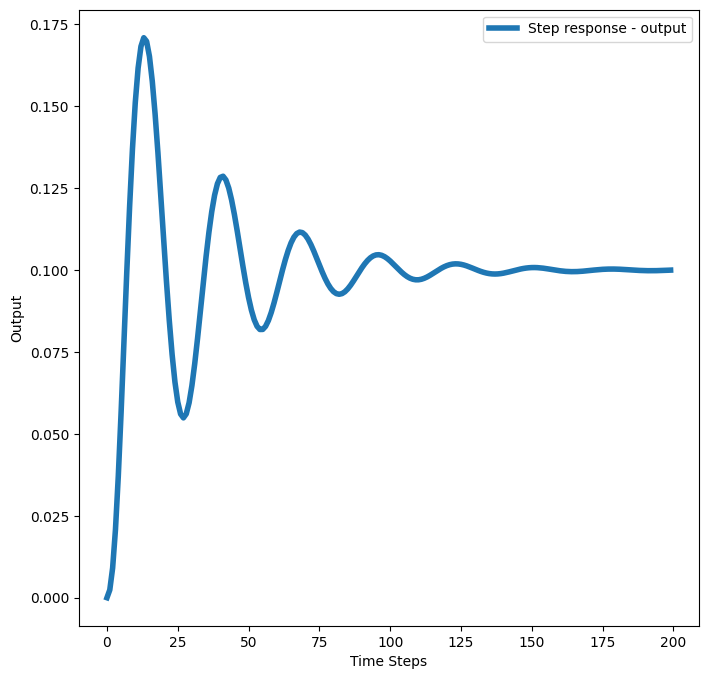

In [4]:
#discretization constant
sampling = 0.05

#model discretization 
I = np.identity(Ac.shape[0])
A = np.linalg.inv(I-sampling*Ac)
B = A*sampling*Bc
C = Cc

#checking the eigen values 
eigen_A = np.linalg.eig(Ac)[0]
eigen_Aid = np.linalg.eig(A)[0]

timeSampleTest = 200

#computingthe system's step response
inputTest = 10*np.ones((1,timeSampleTest))
x0test = np.zeros(shape=(4,1))

#simulating the discrete-time system 
Ytest, Xtest = systemSimulate(A,B,C,inputTest,x0test)

#plotting
plt.figure(figsize=(8,8))
plt.plot(Ytest[0,:],linewidth=4, label='Step response - output')
plt.xlabel('Time Steps')
plt.ylabel('Output')
plt.legend()
#plt.savefig('StepResponse_1.png',dpi=600)
plt.show()

# Formulating wighting matrices

In [5]:
#W1
W1=np.zeros(shape=(v*m,v*m))
 
for i in range(v):
    if (i==0):
        W1[i*m:(i+1)*m,i*m:(i+1)*m]=np.eye(m,m)
    else:
        W1[i*m:(i+1)*m,i*m:(i+1)*m]=np.eye(m,m)
        W1[i*m:(i+1)*m,(i-1)*m:(i)*m]=-np.eye(m,m)

#W2
Q0=0.0000000011
Qother=0.0001
 
W2=np.zeros(shape=(v*m,v*m))
 
for i in range(v):
    if (i==0):
        W2[i*m:(i+1)*m,i*m:(i+1)*m]=Q0
    else:
        W2[i*m:(i+1)*m,i*m:(i+1)*m]=Qother

#W3
W3=np.matmul(W1.T,np.matmul(W2,W1))

#W4
W4=np.zeros(shape=(f*r,f*r))

#in general case, this constant should bea matrix
predWeight = 10

for i in range(f):
    W4[i*r:(i+1)*r,i*r:(i+1)*r]=predWeight

# Defining Reference Trajectory

In [6]:
timeSteps = 300

# #exponential trajectory 
# timeVector=np.linspace(0,100,timeSteps)
# desiredTrajectory=np.ones(timeSteps)-np.exp(-0.01*timeVector)
# desiredTrajectory=np.reshape(desiredTrajectory,(timeSteps,1))

#pulse trajectory 
# desiredTrajectory=np.zeros(shape=(timeSteps,1))
# desiredTrajectory[0:100,:]=np.ones((100,1))
# desiredTrajectory[200:,:]=np.ones((100,1))

#step trajectory
timeSteps=300
desiredTrajectory=0.3*np.ones(shape=(timeSteps,1))

# Simulating the MPC algorithm and plotting the results

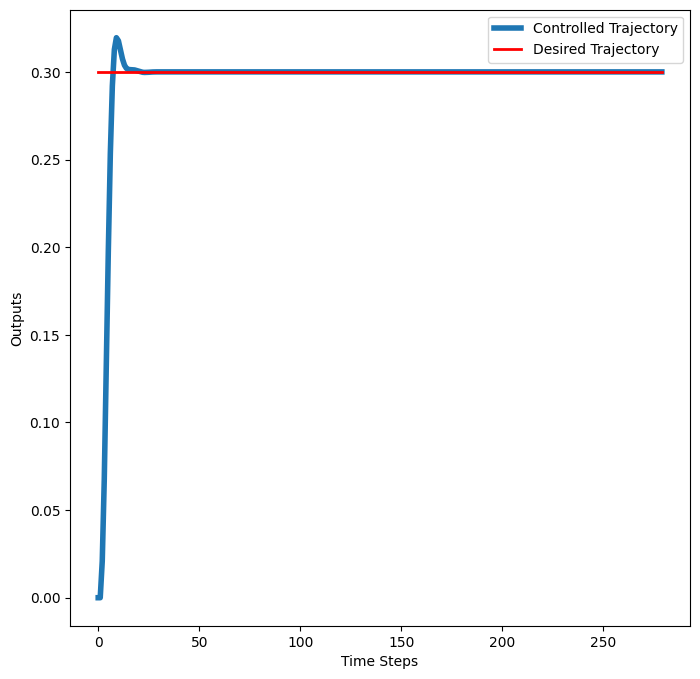

In [7]:
#initial state
x0=x0test

#creating MPC object 
mpc = ModelPredictiveControl(A,B,C,f,v,W3,W4,x0,desiredTrajectory)

#simulating the controller 
for i in range(timeSteps-f):
    mpc.computeControlInputs()

#extracting the state estimates in order to plot results
desiredTrajectoryList=[]
controlledTrajectoryList=[]
controlInputList=[]
for j in np.arange(timeSteps-f):
    controlledTrajectoryList.append(mpc.outputs[j][0,0])
    desiredTrajectoryList.append(desiredTrajectory[j,0])
    controlInputList.append(mpc.inputs[j][0,0])

#plotting the results
plt.figure(figsize=(8,8))
plt.plot(controlledTrajectoryList,linewidth=4,label='Controlled Trajectory')
plt.plot(desiredTrajectoryList, 'r', linewidth=2, label='Desired Trajectory')
plt.xlabel('Time Steps')
plt.ylabel('Outputs')
plt.legend()
#plt.savefig('controlledOutputs_1.png',dpi=600)
plt.show()

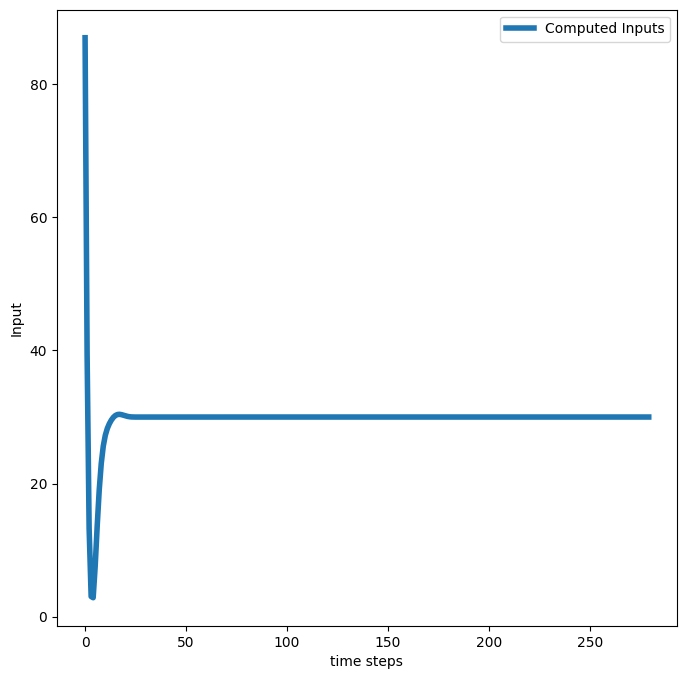

In [8]:
plt.figure(figsize=(8,8))
plt.plot(controlInputList,linewidth=4, label ='Computed Inputs')
plt.xlabel('time steps')
plt.ylabel('Input')
plt.legend()
#plt.savefig('inputs_1.png',dpi=600)
plt.show()